<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_12_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from Bio import Entrez, SeqIO

Entrez.email = "uruguay_sux@example.com"

# 10 human genes (RefSeq mRNA accession numbers)
accessions = {
    "BRCA1": "NM_007294",
    "TP53":  "NM_000546",
    "EGFR":  "NM_005228",
    "INS":   "NM_000207",
    "MYC":   "NM_002467",
    "APOE":  "NM_000041",
    "CFTR":  "NM_000492",
    "VEGFA": "NM_001025366",
    "PTEN":  "NM_000314",
    "KRAS":  "NM_004985"
}

sequences = {}

for gene_name, acc in accessions.items():
    handle = Entrez.efetch(db="nucleotide", id=acc, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    sequences[gene_name] = str(record.seq)
    print(f"Downloaded {gene_name} ({acc}) — length {len(record.seq)}")

print("\nAll 10 gene sequences downloaded.")

Downloaded BRCA1 (NM_007294) — length 7088
Downloaded TP53 (NM_000546) — length 2512
Downloaded EGFR (NM_005228) — length 9905
Downloaded INS (NM_000207) — length 465
Downloaded MYC (NM_002467) — length 3721
Downloaded APOE (NM_000041) — length 1166
Downloaded CFTR (NM_000492) — length 6070
Downloaded VEGFA (NM_001025366) — length 3660
Downloaded PTEN (NM_000314) — length 8515
Downloaded KRAS (NM_004985) — length 5306

All 10 gene sequences downloaded.


In [ ]:
# Save to FASTA file
with open("genes.fasta", "w") as f:
    for gene_name, seq in sequences.items():
        f.write(f">{gene_name}\n{seq}\n")

print("FASTA file created: genes.fasta")

FASTA file created: genes.fasta


In [ ]:
# Print length of each gene
for gene, seq in sequences.items():
  length = len(seq)
  print(gene, length)

BRCA1 7088
TP53 2512
EGFR 9905
INS 465
MYC 3721
APOE 1166
CFTR 6070
VEGFA 3660
PTEN 8515
KRAS 5306


In [ ]:
# GC content function
def gc_content(sequence):
  g = sequence. count("G")
  c = sequence.count("C")
  gc =((g+c)/len(sequence))*100
  return round(gc,2)

In [ ]:
# Test GC content
print(gc_content(sequences["BRCA1"]))

41.77


In [ ]:
# AT Content function
def at_content(sequence):
  a = sequence. count("A")
  t = sequence.count("T")
  at =((a+t)/len(sequence))*100
  return round(at,2)

In [ ]:
# Test AT Content
print(at_content(sequences["BRCA1"]))

58.23


In [ ]:
# Dinucleotide frequency function
from collections import Counter

def dinucleotide_freq(sequence):
    dinucs = []
    for i in range(len(sequence) - 1):
        dinucs.append(sequence[i:i+2])
    return Counter(dinucs)

In [ ]:
# Test dinucleotide frequency
dinucleotide_freq(sequences["BRCA1"])

Counter({'GC': 306,
         'CT': 453,
         'TG': 529,
         'GA': 565,
         'AG': 648,
         'AC': 361,
         'TT': 470,
         'TC': 379,
         'CC': 330,
         'GG': 353,
         'CG': 54,
         'CA': 539,
         'GT': 361,
         'AT': 475,
         'TA': 381,
         'AA': 883})

In [ ]:
# dashboard with all 10 genes
import pandas as pd

results = []
for gene, seq in sequences.items():
    results.append([
        gene,
        len(seq),
        gc_content(seq),
        at_content(seq)
    ])

dashboard = pd.DataFrame(
    results,
    columns=["Gene", "Length", "GC%", "AT%"]
)
dashboard

,Gene,Length,GC%,AT%
0,BRCA1,7088,41.77,58.23
1,TP53,2512,53.38,46.62
2,EGFR,9905,47.78,52.22
3,INS,465,63.87,36.13
4,MYC,3721,48.78,51.22
5,APOE,1166,69.04,30.96
6,CFTR,6070,40.91,59.09
7,VEGFA,3660,51.48,48.52
8,PTEN,8515,36.72,63.28
9,KRAS,5306,36.28,63.72


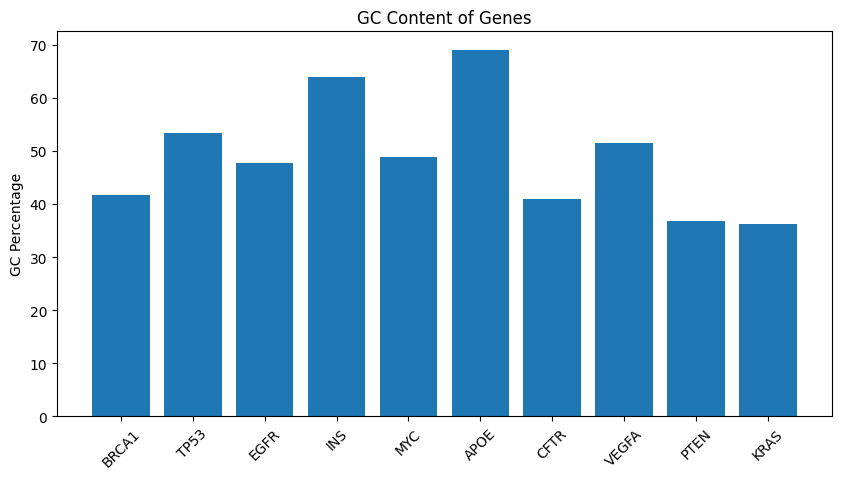

In [ ]:
# GC% bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    dashboard["Gene"],
    dashboard["GC%"]
)
plt.title("GC Content of Genes")
plt.ylabel("GC Percentage")
plt.xticks(rotation=45)
plt.show()

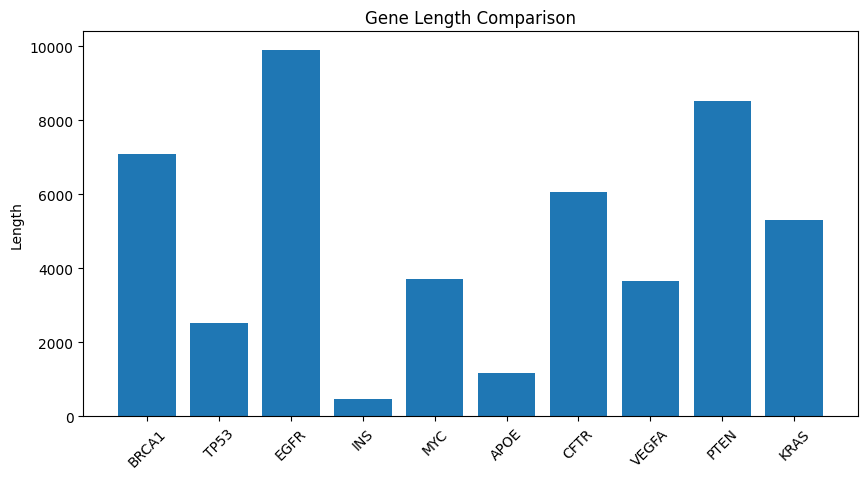

In [ ]:
# Gene length bar chart
plt.figure(figsize=(10,5))

plt.bar(
    dashboard["Gene"],
    dashboard["Length"]
)
plt.title("Gene Length Comparison")
plt.ylabel("Length")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Dinucleotide frequency for BRCA1
brca1_dinuc = dinucleotide_freq(sequences["BRCA1"])
print(brca1_dinuc)

Counter({'AA': 883, 'AG': 648, 'GA': 565, 'CA': 539, 'TG': 529, 'AT': 475, 'TT': 470, 'CT': 453, 'TA': 381, 'TC': 379, 'AC': 361, 'GT': 361, 'GG': 353, 'CC': 330, 'GC': 306, 'CG': 54})


In [ ]:
# Covert to DataFrame
dinuc_df = pd.DataFrame(
    brca1_dinuc.items(),
    columns=["Dinucleotide", "Count"]
)
dinuc_df

,Dinucleotide,Count
0,GC,306
1,CT,453
2,TG,529
3,GA,565
4,AG,648
5,AC,361
6,TT,470
7,TC,379
8,CC,330
9,GG,353


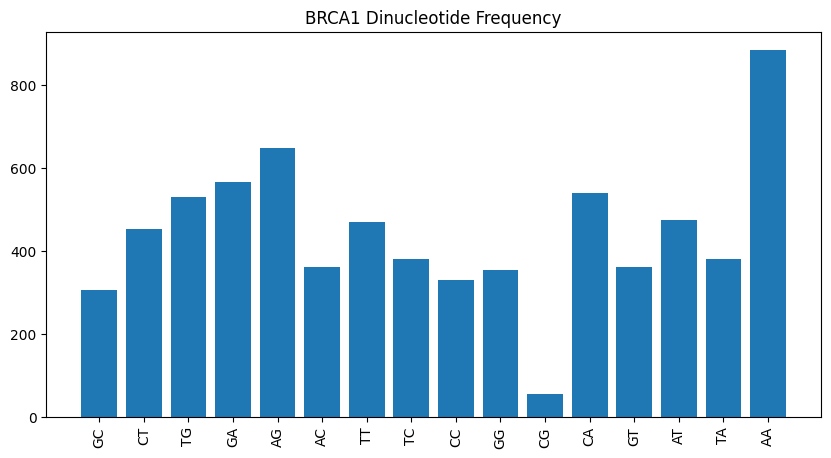

In [ ]:
# Dinucleotide bar chart
plt.figure(figsize=(10,5))

plt.bar(
    dinuc_df["Dinucleotide"],
    dinuc_df["Count"]
)
plt.title("BRCA1 Dinucleotide Frequency")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Final dashboard printout
print("="*40)
print("GC CONTENT DASHBOARD")
print("="*40)
print(dashboard)
print("="*40)

GC CONTENT DASHBOARD
    Gene  Length    GC%    AT%
0  BRCA1    7088  41.77  58.23
1   TP53    2512  53.38  46.62
2   EGFR    9905  47.78  52.22
3    INS     465  63.87  36.13
4    MYC    3721  48.78  51.22
5   APOE    1166  69.04  30.96
6   CFTR    6070  40.91  59.09
7  VEGFA    3660  51.48  48.52
8   PTEN    8515  36.72  63.28
9   KRAS    5306  36.28  63.72
